# California Housing Price Prediction

## Objective
Build and evaluate a Linear Regression model using the California Housing Dataset.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pickle

In [2]:
#Load Dataset
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df["HousePrice"] = housing.target

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
#Dataset Overview
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.head()

Dataset Shape: (20640, 9)

Column Names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'HousePrice']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
#Missing Values Check
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64


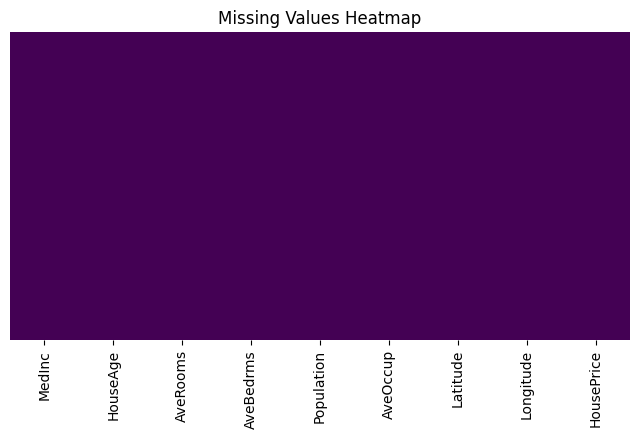

In [7]:
#Visualization
plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

In [8]:
#Statistical Summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [9]:
#Check Duplicate Records
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


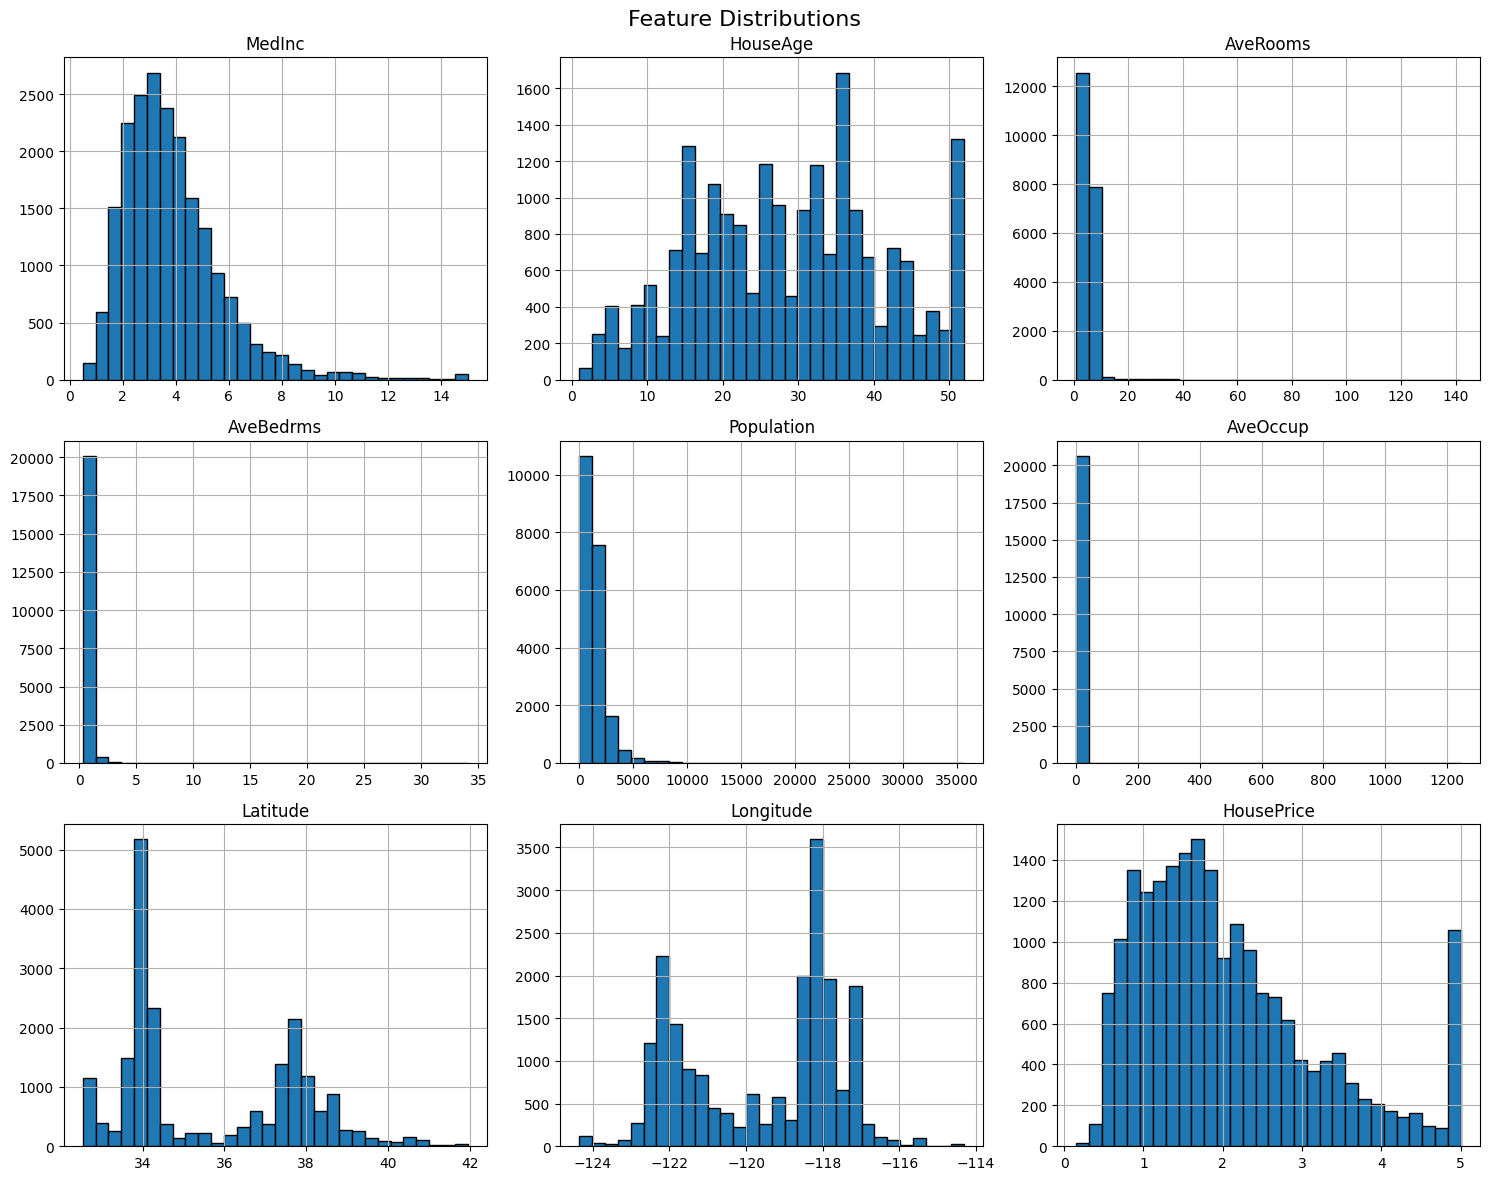

In [10]:
#Histograms of All Features
df.hist(
    figsize=(15,12),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Feature Distributions", fontsize=16)

plt.tight_layout()

plt.show()

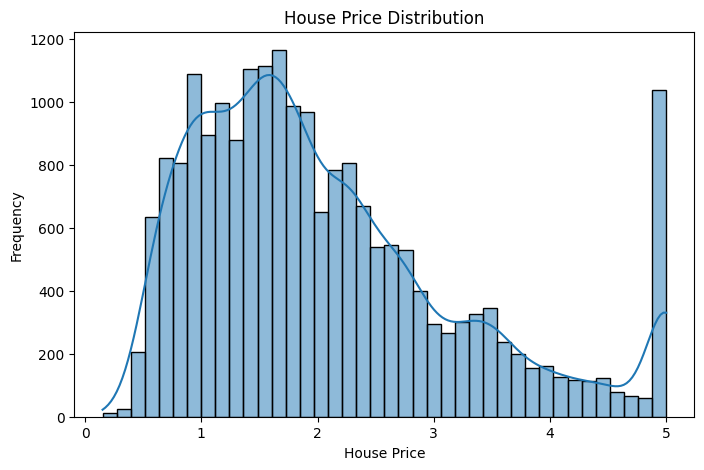

In [11]:
#Target Variable Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["HousePrice"],
    bins=40,
    kde=True
)

plt.title("House Price Distribution")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

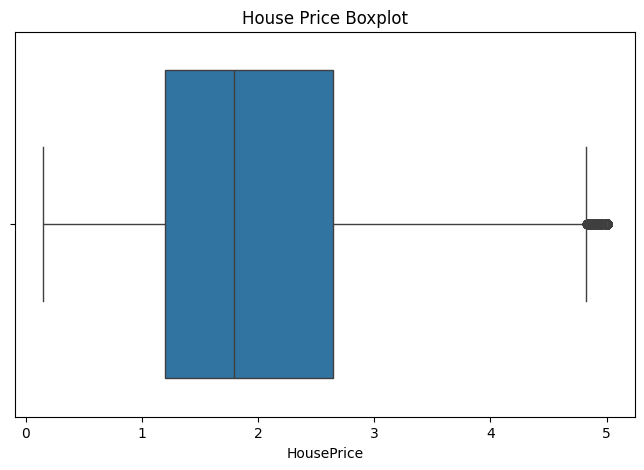

In [12]:
#Boxplot for Target Variable
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["HousePrice"]
)

plt.title("House Price Boxplot")

plt.show()

In [13]:
#Correlation Matrix
correlation_matrix = df.corr()

correlation_matrix

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
HousePrice,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


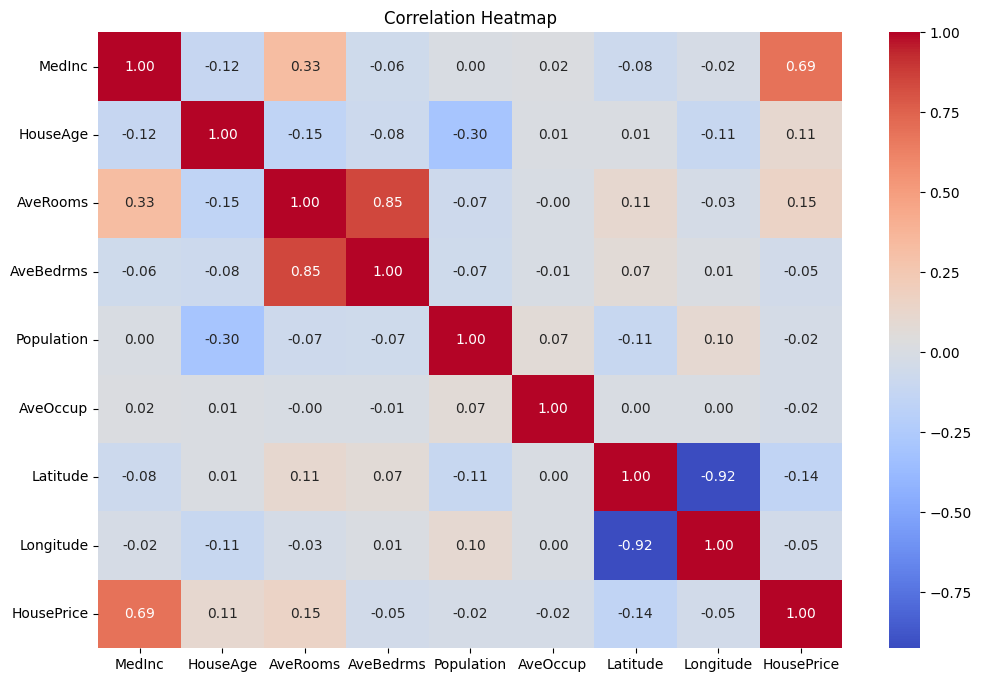

In [14]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

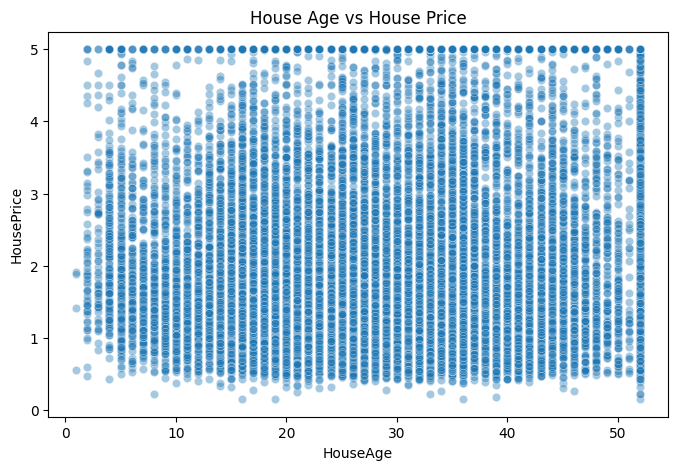

In [15]:
#Median Income vs House Price
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="HouseAge",
    y="HousePrice",
    alpha=0.4
)

plt.title("House Age vs House Price")

plt.show()

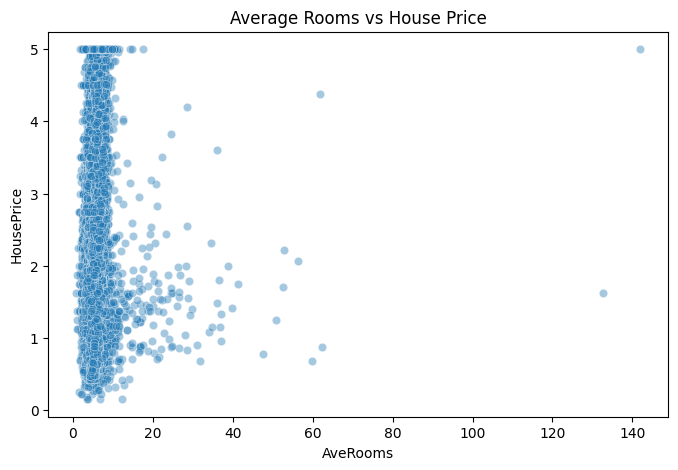

In [16]:
#Average Rooms vs House Price
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="AveRooms",
    y="HousePrice",
    alpha=0.4
)

plt.title("Average Rooms vs House Price")

plt.show()

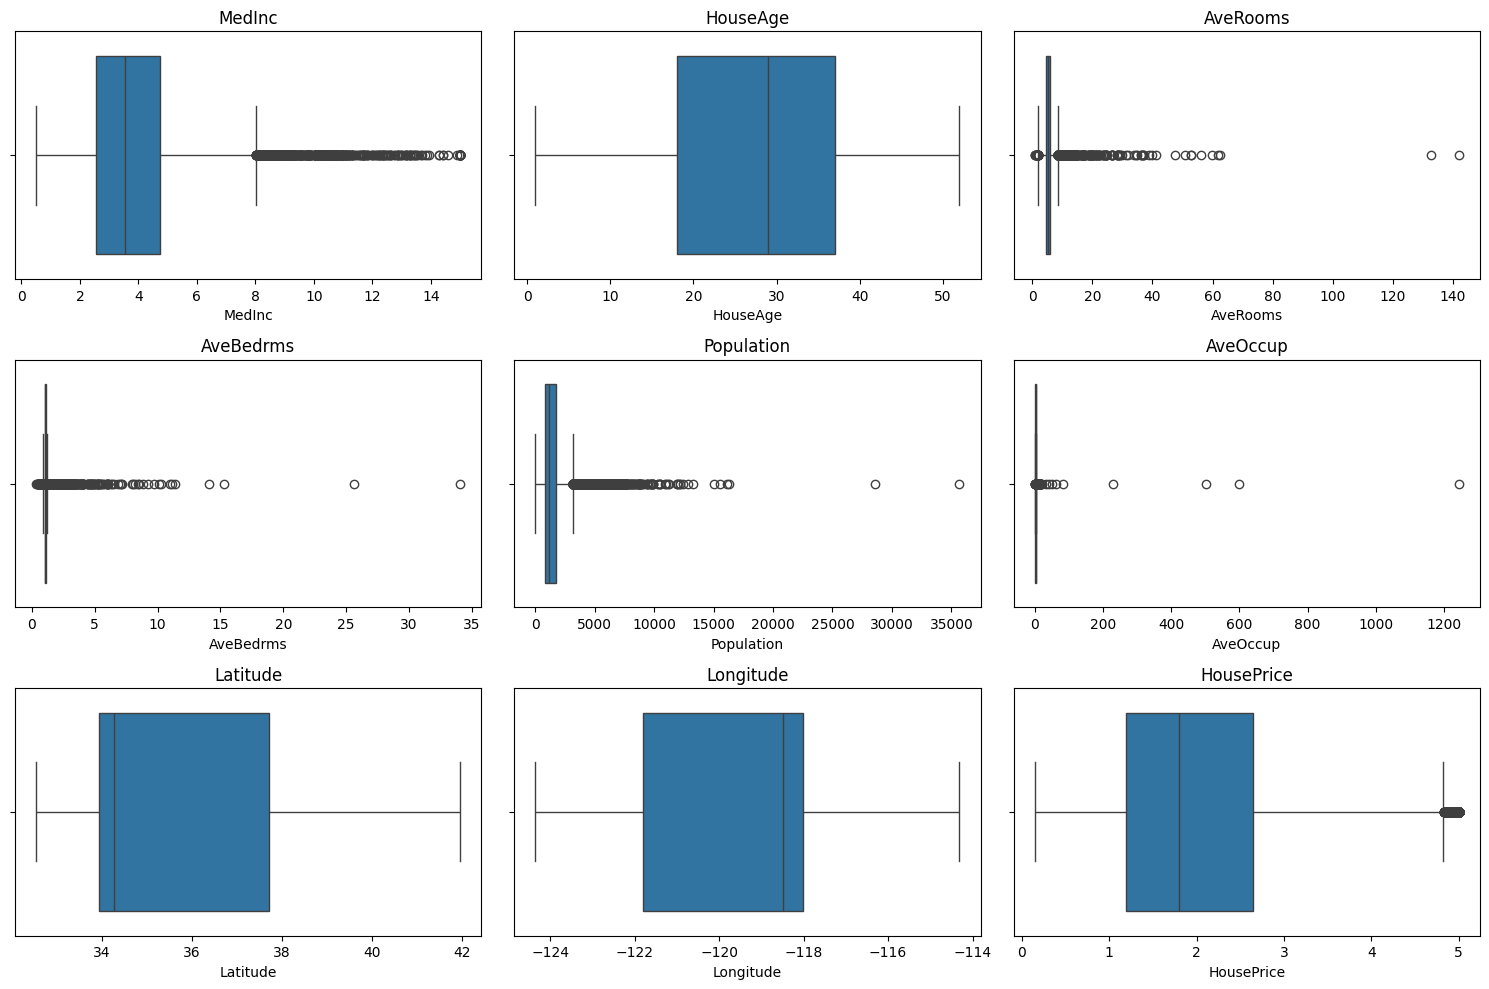

In [17]:
#Boxplots for Numerical Features
plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns, 1):

    plt.subplot(3, 3, i)

    sns.boxplot(
        x=df[column]
    )

    plt.title(column)

plt.tight_layout()

plt.show()

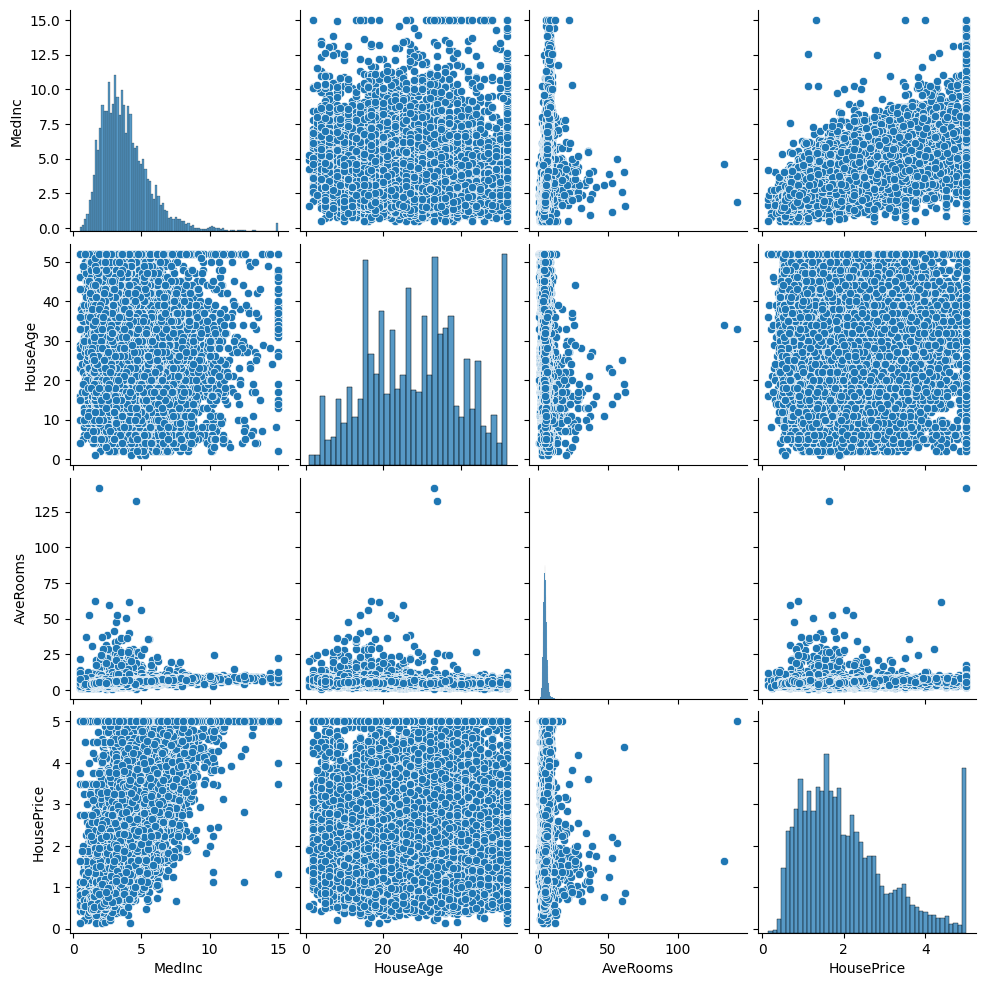

In [18]:
#Pairplot
selected_columns = [
    "MedInc",
    "HouseAge",
    "AveRooms",
    "HousePrice"
]

sns.pairplot(df[selected_columns])

plt.show()

In [19]:
#Target Correlation Ranking
target_corr = (
    df.corr()["HousePrice"]
    .sort_values(ascending=False)
)

print(target_corr)

HousePrice    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HousePrice, dtype: float64


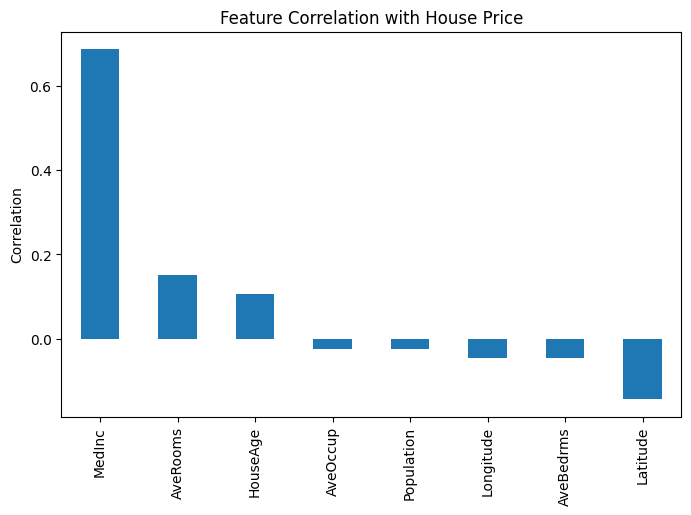

In [20]:
#Visualization
plt.figure(figsize=(8,5))

target_corr.drop("HousePrice").plot(
    kind="bar"
)

plt.title(
    "Feature Correlation with House Price"
)

plt.ylabel("Correlation")

plt.show()

In [23]:
#Split Data
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (16512, 8)
Testing Shape: (4128, 8)


In [24]:
#Train Model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [25]:
#Predictions
y_pred = model.predict(X_test)

print("First 10 Predictions")

for i in range(10):
    print(
        f"Actual: {y_test.iloc[i]:.2f} | Predicted: {y_pred[i]:.2f}"
    )

First 10 Predictions
Actual: 0.48 | Predicted: 0.72
Actual: 0.46 | Predicted: 1.76
Actual: 5.00 | Predicted: 2.71
Actual: 2.19 | Predicted: 2.84
Actual: 2.78 | Predicted: 2.60
Actual: 1.59 | Predicted: 2.01
Actual: 1.98 | Predicted: 2.65
Actual: 1.57 | Predicted: 2.17
Actual: 3.40 | Predicted: 2.74
Actual: 4.47 | Predicted: 3.92


In [26]:
#Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,4))
print("RMSE:", round(rmse,4))
print("R² Score:", round(r2,4))

MAE : 0.5332
RMSE: 0.7456
R² Score: 0.5758


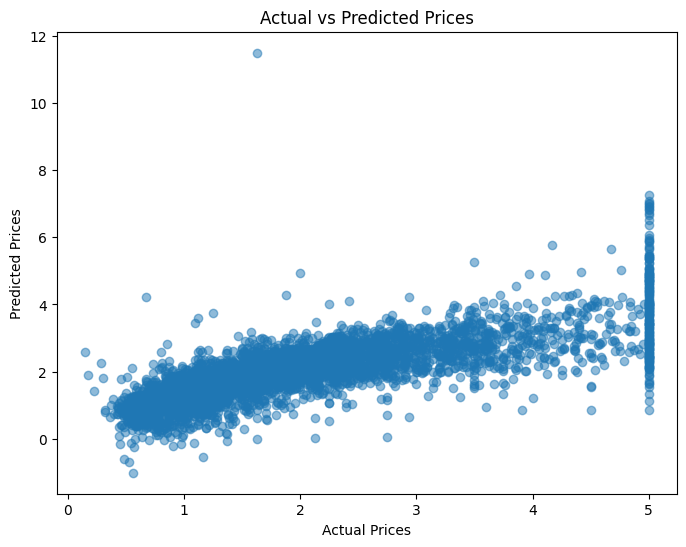

In [27]:
#Actual vs Predicted Plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.show()

In [28]:
#Feature Importance
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [29]:
#Save Model
with open(
    "house_price_model.pkl",
    "wb"
) as file:
    pickle.dump(model, file)

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
#Test Saved Model
loaded_model = pickle.load(
    open(
        "house_price_model.pkl",
        "rb"
    )
)

sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted House Price:", prediction[0])

Predicted House Price: 0.7191228416019158
